In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import f1_score

In [2]:
milo = pd.read_csv('data/milo_clean.csv')

# note: this notebook runs on the full cleaned dataset (~451k rows)
# runtime is roughly 15-30 minutes depending on your machine
# the RandomizedSearchCV cells are the slowest parts

milo.corr(numeric_only=True)['improved'].sort_values(ascending=False)

improved                                1.000000
bodyweight_change_band_gained_5plus     0.171118
bodyweight_change_band_gained_2_to_5    0.139247
days_band_180_to_365                    0.133762
days_band_90_to_180                     0.105743
age_band_25_to_30                       0.071407
age_band_under_20                       0.051501
days_band_over_365                      0.046746
prev_deadlift_band_dl_under_120         0.044498
prev_total_band_under_300               0.041591
days_band_30_to_90                      0.038931
age_band_30_to_35                       0.035261
prev_squat_band_sq_under_100            0.033302
prev_bench_band_bp_under_60             0.033215
prev_total_band_450_to_600              0.032410
prev_bench_band_bp_90_to_120            0.027853
age_band_20_to_25                       0.026351
prev_squat_band_sq_150_to_200           0.025091
prev_deadlift_band_dl_175_to_230        0.024063
prev_squat_band_sq_100_to_150           0.012166
prev_deadlift_band_d

In [3]:
# prepare features (X) and target (y) for modelling
#
# X is everything except 'improved' — these are the inputs the model learns from
# y is just 'improved' — this is what the model tries to predict
#
# We also drop one dummy column per category group (the drop_reference list below).
# This avoids the dummy variable trap: if you keep all dummies for a group,
# one column is always perfectly predictable from the others (they add up to 1),
# which confuses the model. Dropping one per group fixes this.
# The dropped column becomes the "reference" — all other bands are compared against it.

drop_reference = [
    'days_band_over_365',             # reference: longest break between sessions
    'bodyweight_change_band_stable',  # reference: no weight change
    'prev_total_band_over_750',       # reference: elite total
    'prev_squat_band_sq_over_250',    # reference: elite squat
    'prev_bench_band_bp_over_150',    # reference: elite bench
    'prev_deadlift_band_dl_over_280', # reference: elite deadlift
    'age_band_over_45',               # reference: oldest age group
]

X = milo.drop(columns=['improved'] + drop_reference)
y = milo['improved']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                            shuffle=True, random_state=72)
cv = KFold(n_splits=3, shuffle=True, random_state=72)

In [4]:
#let us see the class balance in the training set we know from the cleaning there is some inbalance
display(round(y_train.value_counts() / y_train.shape[0], 3))

# improved = 1 means the lifter increased their total
# improved = 0 means they stayed the same or declined
# if there is a class imbalance we will evaluate with both accuracy and F1-score
# and search for the decision threshold that optimises each metric

improved
True     0.616
False    0.384
Name: count, dtype: float64

In [5]:
# Simplest possibe test that always predicts the majority class
#this is our baseline to see how useful any model actually is

majority_class = int(y_train.mode()[0])
y_pred_test_mc = np.full(len(y_test), majority_class)
y_pred_train_mc = np.full(len(y_train), majority_class)

print(f'Accuracy test Most Common: {accuracy_score(y_test, y_pred_test_mc):.3f}')
print(f'Accuracy train Most Common: {accuracy_score(y_train, y_pred_train_mc):.3f}')
print(f'F1-score test Most Common: {f1_score(y_test, y_pred_test_mc):.3f}')
print(f'F1-score train Most Common: {f1_score(y_train, y_pred_train_mc):.3f}')

Accuracy test Most Common: 0.615
Accuracy train Most Common: 0.616
F1-score test Most Common: 0.761
F1-score train Most Common: 0.763


In [6]:
#Test 2: Naive Bayes
nbc = GaussianNB()
nbc.fit(X_train, y_train)

y_pred_train_bayes = nbc.predict(X_train)
y_pred_test_bayes = nbc.predict(X_test)
p_nbc_test = nbc.predict_proba(X_test)[:, 1]

print(f'Accuracy test Bayes: {accuracy_score(y_test, y_pred_test_bayes):.3f}')
print(f'Accuracy train Bayes: {accuracy_score(y_train, y_pred_train_bayes):.3f}')
print(f'F1-score test Bayes: {f1_score(y_test, y_pred_test_bayes):.3f}')
print(f'F1-score train Bayes: {f1_score(y_train, y_pred_train_bayes):.3f}')

# Naive Bayes assumes all features are independent of each other
# because our dummy variables within a group are perfectly correlated (only one can be True)
# this assumption is violated - so we expect poor performance here

Accuracy test Bayes: 0.716
Accuracy train Bayes: 0.718
F1-score test Bayes: 0.784
F1-score train Bayes: 0.785


In [7]:
#find the best threshold for accuracy for Naive Bayes
p_nbc_train = nbc.predict_proba(X_train)[:, 1]
thresholds = np.linspace(0.01, 0.99, 99)
best_t_Bayes_acc = 0.5
best_acc = 0

for t in thresholds:
    preds = (p_nbc_train >= t).astype(int)
    acc = accuracy_score(y_train, preds)
    if acc > best_acc:
        best_acc = acc
        best_t_Bayes_acc = t

y_pred_test_bayes_tunedacc = (p_nbc_test >= best_t_Bayes_acc).astype(int)
print(f'Best threshold: {best_t_Bayes_acc:.3f}')
print(f'Accuracy test Bayes with tuned threshold: {accuracy_score(y_test, y_pred_test_bayes_tunedacc):.3f}')

Best threshold: 0.110
Accuracy test Bayes with tuned threshold: 0.734


In [8]:
#find the best threshold for F1-score for Naive Bayes
best_t_Bayes_f1 = 0.5
best_f1 = 0

for t in thresholds:
    preds = (p_nbc_train >= t).astype(int)
    f1 = f1_score(y_train, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_t_Bayes_f1 = t

y_pred_test_bayes_tunedf1 = (p_nbc_test >= best_t_Bayes_f1).astype(int)
print(f'Best threshold: {best_t_Bayes_f1:.3f}')
print(f'F1-score test Bayes with tuned threshold: {f1_score(y_test, y_pred_test_bayes_tunedf1):.3f}')

Best threshold: 0.010
F1-score test Bayes with tuned threshold: 0.813


In [9]:
#Test 3: Logistic Regression (no penalty)
# minimises log-loss using gradient descent
# does not assume feature independence unlike Naive Bayes
lrc = LogisticRegression(max_iter=5000, penalty=None)
lrc.fit(X_train, y_train)

y_pred_train_lrc = lrc.predict(X_train)
y_pred_test_lrc = lrc.predict(X_test)
p_lrc_test = lrc.predict_proba(X_test)[:, 1]

print(f'Accuracy test LogReg: {accuracy_score(y_test, y_pred_test_lrc):.3f}')
print(f'Accuracy train LogReg: {accuracy_score(y_train, y_pred_train_lrc):.3f}')
print(f'F1-score test LogReg: {f1_score(y_test, y_pred_test_lrc):.3f}')
print(f'F1-score train LogReg: {f1_score(y_train, y_pred_train_lrc):.3f}')

Accuracy test LogReg: 0.736
Accuracy train LogReg: 0.738
F1-score test LogReg: 0.810
F1-score train LogReg: 0.812


In [10]:
#threshold tuning for Logistic Regression - accuracy
p_lrc_train = lrc.predict_proba(X_train)[:, 1]
best_threshold_lrc_acc = 0.5
best_accuracy = -1

for t in thresholds:
    preds = (p_lrc_train >= t).astype(int)
    acc = accuracy_score(y_train, preds)
    if acc > best_accuracy:
        best_accuracy = acc
        best_threshold_lrc_acc = t

p_lrc_test_prob = lrc.predict_proba(X_test)[:, 1]
y_pred_lrcacc_test_best_thresh = (p_lrc_test_prob >= best_threshold_lrc_acc).astype(int)
print(f'Best accuracy: {best_accuracy:.3f}  |  Best threshold: {best_threshold_lrc_acc:.3f}')
print(f'Accuracy test LogReg tuned: {accuracy_score(y_test, y_pred_lrcacc_test_best_thresh):.3f}')

Best accuracy: 0.738  |  Best threshold: 0.480
Accuracy test LogReg tuned: 0.736


In [11]:
#threshold tuning for Logistic Regression - F1
best_threshold_lrc_f1 = 0.5
best_f1 = -1

for t in thresholds:
    preds = (p_lrc_train >= t).astype(int)
    f1 = f1_score(y_train, preds, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold_lrc_f1 = t

y_pred_lrcf1_test_best_thresh = (p_lrc_test_prob >= best_threshold_lrc_f1).astype(int)
print(f'Best F1: {best_f1:.3f}  |  Best threshold: {best_threshold_lrc_f1:.3f}')
print(f'F1-score test LogReg tuned: {f1_score(y_test, y_pred_lrcf1_test_best_thresh):.3f}')

Best F1: 0.816  |  Best threshold: 0.390
F1-score test LogReg tuned: 0.815


In [12]:
#Test 4: Logistic Regression with Lasso (L1) penalty
# L1 penalty drives some coefficients all the way to zero which effectively removes features
# useful when we have many dummy variables and some might not matter
lrc_lasso = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000, random_state=72)
lrc_lasso.fit(X_train, y_train)

y_pred_train_lrc_lasso = lrc_lasso.predict(X_train)
y_pred_test_lrc_lasso = lrc_lasso.predict(X_test)
p_lrc_lasso_test = lrc_lasso.predict_proba(X_test)[:, 1]

print(f'Accuracy test LogReg Lasso: {accuracy_score(y_test, y_pred_test_lrc_lasso):.3f}')
print(f'Accuracy train LogReg Lasso: {accuracy_score(y_train, y_pred_train_lrc_lasso):.3f}')
print(f'F1-score test LogReg Lasso: {f1_score(y_test, y_pred_test_lrc_lasso):.3f}')
print(f'F1-score train LogReg Lasso: {f1_score(y_train, y_pred_train_lrc_lasso):.3f}')

Accuracy test LogReg Lasso: 0.736
Accuracy train LogReg Lasso: 0.738
F1-score test LogReg Lasso: 0.810
F1-score train LogReg Lasso: 0.812


In [13]:
#threshold tuning for Lasso - accuracy
p_lasso_train = lrc_lasso.predict_proba(X_train)[:, 1]
best_threshold_lrc_lasso_acc = 0.5
best_accuracy = -1

for t in thresholds:
    preds = (p_lasso_train >= t).astype(int)
    acc = accuracy_score(y_train, preds)
    if acc > best_accuracy:
        best_accuracy = acc
        best_threshold_lrc_lasso_acc = t

y_pred_lrcacc_lasso_test_best_thresh = (p_lrc_lasso_test >= best_threshold_lrc_lasso_acc).astype(int)
print(f'Best accuracy: {best_accuracy:.3f}  |  Best threshold: {best_threshold_lrc_lasso_acc:.3f}')
print(f'Accuracy test LogReg Lasso tuned: {accuracy_score(y_test, y_pred_lrcacc_lasso_test_best_thresh):.3f}')

Best accuracy: 0.738  |  Best threshold: 0.470
Accuracy test LogReg Lasso tuned: 0.736


In [14]:
#threshold tuning for Lasso - F1
best_threshold_lrc_lasso_f1 = 0.5
best_f1 = -1

for t in thresholds:
    preds = (p_lasso_train >= t).astype(int)
    f1 = f1_score(y_train, preds, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold_lrc_lasso_f1 = t

y_pred_lrcf1_lasso_test_best_thresh = (p_lrc_lasso_test >= best_threshold_lrc_lasso_f1).astype(int)
print(f'Best F1: {best_f1:.3f} Best threshold: {best_threshold_lrc_lasso_f1:.3f}')
print(f'F1-score test LogReg Lasso tuned: {f1_score(y_test, y_pred_lrcf1_lasso_test_best_thresh):.3f}')

Best F1: 0.816 Best threshold: 0.390
F1-score test LogReg Lasso tuned: 0.815


In [15]:
#Test 5: Logistic Regression with Ridge (L2) penalty
# unlike L1, Ridge shrinks all coefficients towards zero but does not zero them out
# better when all features are genuinely relevant
lrc_ridge = LogisticRegression(penalty='l2', max_iter=5000)
lrc_ridge.fit(X_train, y_train)

y_pred_train_lrc_ridge = lrc_ridge.predict(X_train)
y_pred_test_lrc_ridge = lrc_ridge.predict(X_test)
p_lrc_ridge_test = lrc_ridge.predict_proba(X_test)[:, 1]

print(f'Accuracy test LogReg Ridge: {accuracy_score(y_test, y_pred_test_lrc_ridge):.3f}')
print(f'Accuracy train LogReg Ridge: {accuracy_score(y_train, y_pred_train_lrc_ridge):.3f}')
print(f'F1-score test LogReg Ridge: {f1_score(y_test, y_pred_test_lrc_ridge):.3f}')
print(f'F1-score train LogReg Ridge: {f1_score(y_train, y_pred_train_lrc_ridge):.3f}')

Accuracy test LogReg Ridge: 0.736
Accuracy train LogReg Ridge: 0.738
F1-score test LogReg Ridge: 0.810
F1-score train LogReg Ridge: 0.812


In [16]:
#threshold tuning for Ridge - accuracy
p_ridge_train = lrc_ridge.predict_proba(X_train)[:, 1]
best_threshold_lrc_ridge_acc = 0.5
best_accuracy = -1

for t in thresholds:
    preds = (p_ridge_train >= t).astype(int)
    acc = accuracy_score(y_train, preds)
    if acc > best_accuracy:
        best_accuracy = acc
        best_threshold_lrc_ridge_acc = t

y_pred_lrcacc_ridge_test_best_thresh = (p_lrc_ridge_test >= best_threshold_lrc_ridge_acc).astype(int)
print(f'Best accuracy: {best_accuracy:.3f}  |  Best threshold: {best_threshold_lrc_ridge_acc:.3f}')
print(f'Accuracy test LogReg Ridge tuned: {accuracy_score(y_test, y_pred_lrcacc_ridge_test_best_thresh):.3f}')

Best accuracy: 0.738  |  Best threshold: 0.480
Accuracy test LogReg Ridge tuned: 0.736


In [17]:
#threshold tuning for Ridge - F1
best_threshold_lrc_ridge_f1 = 0.5
best_f1 = -1

for t in thresholds:
    preds = (p_ridge_train >= t).astype(int)
    f1 = f1_score(y_train, preds, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold_lrc_ridge_f1 = t

y_pred_lrcf1_ridge_test_best_thresh = (p_lrc_ridge_test >= best_threshold_lrc_ridge_f1).astype(int)
print(f'Best F1: {best_f1:.3f}  |  Best threshold: {best_threshold_lrc_ridge_f1:.3f}')
print(f'F1-score test LogReg Ridge tuned: {f1_score(y_test, y_pred_lrcf1_ridge_test_best_thresh):.3f}')

Best F1: 0.816  |  Best threshold: 0.390
F1-score test LogReg Ridge tuned: 0.815


In [18]:
#Test 6: Random Forest
# Random Forest builds many decision trees on random bootstrap samples
# at each split it also only considers a random subset of features
# this makes the trees different from each other and reduces overfitting
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200,
                            max_depth=20,
                            min_samples_split=2,
                            min_samples_leaf=1,
                            random_state=72)
rf.fit(X_train, y_train)

y_pred_test_rf = rf.predict(X_test)
y_pred_train_rf = rf.predict(X_train)
p_rf_test = rf.predict_proba(X_test)[:, 1]

print(f'Accuracy test Random Forest: {accuracy_score(y_test, y_pred_test_rf):.5f}')
print(f'Accuracy train Random Forest: {accuracy_score(y_train, y_pred_train_rf):.5f}')
print(f'F1-score test Random Forest: {f1_score(y_test, y_pred_test_rf):.5f}')
print(f'F1-score train Random Forest: {f1_score(y_train, y_pred_train_rf):.5f}')

Accuracy test Random Forest: 0.73499
Accuracy train Random Forest: 0.75093
F1-score test Random Forest: 0.81072
F1-score train Random Forest: 0.82257


In [19]:
#hyperparameter tuning for Random Forest - accuracy
# RandomizedSearchCV normally searches over model hyperparameters (like max_depth or n_estimators).
# It cannot search over the decision threshold because that is not a model parameter.
# To get around this, we wrap the Random Forest inside a custom class that treats the threshold
# as a regular parameter. This lets RandomizedSearchCV tune it alongside the other settings.
# I used a very similar wrapper approach in a past classification project.
from sklearn.base import BaseEstimator, ClassifierMixin

class RFWithThreshold(BaseEstimator, ClassifierMixin):
    def __init__(self, n_estimators=100, max_depth=None, min_samples_split=2,
                 min_samples_leaf=1, max_features='sqrt', threshold=0.5, random_state=72):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.threshold = threshold
        self.random_state = random_state

    def fit(self, X, y):
        self.model_ = RandomForestClassifier(
            n_estimators=self.n_estimators, max_depth=self.max_depth,
            min_samples_split=self.min_samples_split, min_samples_leaf=self.min_samples_leaf,
            max_features=self.max_features, random_state=self.random_state)
        self.model_.fit(X, y)
        return self

    def predict_proba(self, X):
        return self.model_.predict_proba(X)

    def predict(self, X):
        proba = self.predict_proba(X)[:, 1]
        return (proba >= self.threshold).astype(int)


param_distributions = {
    'n_estimators': [100, 200],
    'min_samples_split': [2, 3],
    'max_depth': [10, 20],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt'],
    'threshold': np.linspace(0.1, 0.9, 17),
}

search = RandomizedSearchCV(
    estimator=RFWithThreshold(random_state=72),
    param_distributions=param_distributions,
    n_iter=5,
    scoring='accuracy', cv=cv, refit=True,
    return_train_score=True, random_state=72)
search.fit(X_train, y_train)

y_pred_train_tunedacc_rf = search.predict(X_train)
y_pred_test_tunedacc_rf = search.predict(X_test)

print(f'Best params: {search.best_params_}')
print(f'Accuracy train RF tuned: {accuracy_score(y_train, y_pred_train_tunedacc_rf):.5f}')
print(f'Accuracy test RF tuned:  {accuracy_score(y_test, y_pred_test_tunedacc_rf):.5f}')

Best params: {'threshold': np.float64(0.55), 'n_estimators': 100, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20}
Accuracy train RF tuned: 0.74737
Accuracy test RF tuned:  0.73474


In [20]:
#hyperparameter tuning for Random Forest - F1
searchf1 = RandomizedSearchCV(
    estimator=RFWithThreshold(random_state=72),
    param_distributions=param_distributions,
    n_iter=5,
    scoring='f1', cv=cv, refit=True,
    return_train_score=True, random_state=72)
searchf1.fit(X_train, y_train)

y_pred_train_tunedf1_rf = searchf1.predict(X_train)
y_pred_test_tunedf1_rf = searchf1.predict(X_test)

print(f'Best params: {searchf1.best_params_}')
print(f'F1 train RF tuned: {f1_score(y_train, y_pred_train_tunedf1_rf):.5f}')
print(f'F1 test RF tuned:  {f1_score(y_test, y_pred_test_tunedf1_rf):.5f}')

Best params: {'threshold': np.float64(0.30000000000000004), 'n_estimators': 100, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10}
F1 train RF tuned: 0.81199
F1 test RF tuned:  0.81090


In [21]:
#Test 7: Gradient Boosting
# Boosting builds trees sequentially - each tree corrects the mistakes of the previous one
# a higher learning rate means each tree has a bigger influence but risks overfitting
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import TunedThresholdClassifierCV

gb = HistGradientBoostingClassifier(
    learning_rate=0.05, max_leaf_nodes=30, min_samples_leaf=20,
    early_stopping=True, n_iter_no_change=20,
    validation_fraction=0.2, random_state=72)
gb.fit(X_train, y_train)

y_pred_test_boosting = gb.predict(X_test)
y_pred_train_boosting = gb.predict(X_train)
p_boosting_test = gb.predict_proba(X_test)[:, 1]

print(f'Accuracy test Boosting: {accuracy_score(y_test, y_pred_test_boosting):.3f}')
print(f'Accuracy train Boosting: {accuracy_score(y_train, y_pred_train_boosting):.3f}')
print(f'F1-score test Boosting: {f1_score(y_test, y_pred_test_boosting):.3f}')
print(f'F1-score train Boosting: {f1_score(y_train, y_pred_train_boosting):.3f}')

Accuracy test Boosting: 0.739
Accuracy train Boosting: 0.741
F1-score test Boosting: 0.814
F1-score train Boosting: 0.816


In [22]:
#hyperparameter tuning for Boosting - accuracy
param_dist_gb = {
    'learning_rate': [0.05, 0.5],
    'max_leaf_nodes': [20, 30, 35],
    'min_samples_leaf': [10, 20]
}

search_boosting = RandomizedSearchCV(
    HistGradientBoostingClassifier(early_stopping=True, n_iter_no_change=20,
                                    validation_fraction=0.2, random_state=72),
    param_distributions=param_dist_gb, n_iter=5,
    scoring='accuracy', cv=cv, random_state=72)
search_boosting.fit(X_train, y_train)

boosting_tuned = TunedThresholdClassifierCV(
    estimator=search_boosting.best_estimator_, scoring='accuracy', cv=cv, refit=True)
boosting_tuned.fit(X_train, y_train)

y_pred_test_boostingacc_hyp = boosting_tuned.predict(X_test)
y_pred_train_boostingacc_hyp = boosting_tuned.predict(X_train)
p_boosting_hypacc_test = boosting_tuned.predict_proba(X_test)[:, 1]

print(f'Accuracy test Boosting tuned: {accuracy_score(y_test, y_pred_test_boostingacc_hyp):.3f}')
print(f'Accuracy train Boosting tuned: {accuracy_score(y_train, y_pred_train_boostingacc_hyp):.3f}')
print(f'Best threshold: {boosting_tuned.best_threshold_:.3f}')

Accuracy test Boosting tuned: 0.739
Accuracy train Boosting tuned: 0.741
Best threshold: 0.501


In [23]:
#hyperparameter tuning for Boosting - F1
search_boosting_f1 = RandomizedSearchCV(
    HistGradientBoostingClassifier(early_stopping=True, n_iter_no_change=20,
                                    validation_fraction=0.2, random_state=72),
    param_distributions=param_dist_gb, n_iter=5,
    scoring='f1', cv=cv, random_state=72)
search_boosting_f1.fit(X_train, y_train)

boosting_tuned_f1 = TunedThresholdClassifierCV(
    estimator=search_boosting_f1.best_estimator_, scoring='f1', cv=cv, refit=True)
boosting_tuned_f1.fit(X_train, y_train)

y_pred_test_boostingf1_hyp = boosting_tuned_f1.predict(X_test)
y_pred_train_boostingf1_hyp = boosting_tuned_f1.predict(X_train)
p_boosting_hypf1_test = boosting_tuned_f1.predict_proba(X_test)[:, 1]

print(f'F1-score test Boosting tuned: {f1_score(y_test, y_pred_test_boostingf1_hyp):.3f}')
print(f'F1-score train Boosting tuned: {f1_score(y_train, y_pred_train_boostingf1_hyp):.3f}')
print(f'Best threshold: {boosting_tuned_f1.best_threshold_:.3f}')

F1-score test Boosting tuned: 0.817
F1-score train Boosting tuned: 0.818
Best threshold: 0.404


In [24]:
#Test 8: Neural Network
# stacks multiple layers of neurons and uses non-linear activation functions
# this means the loss function is non-convex so we use stochastic gradient descent
# and fix a random state for reproducibility
from sklearn.neural_network import MLPClassifier

nnet = MLPClassifier(hidden_layer_sizes=(8, 16, 8),
                     learning_rate_init=0.003,
                     activation='relu',
                     solver='sgd',
                     alpha=0.001,
                     batch_size=32,
                     max_iter=500,
                     early_stopping=True,
                     n_iter_no_change=20,
                     random_state=72)
nnet.fit(X_train, y_train)

y_pred_train_neuron = nnet.predict(X_train)
y_pred_test_neuron = nnet.predict(X_test)
p_nnet_test = nnet.predict_proba(X_test)[:, 1]

print(f'Accuracy test Neural Net: {accuracy_score(y_test, y_pred_test_neuron):.3f}')
print(f'Accuracy train Neural Net: {accuracy_score(y_train, y_pred_train_neuron):.3f}')
print(f'F1-score test Neural Net: {f1_score(y_test, y_pred_test_neuron):.3f}')
print(f'F1-score train Neural Net: {f1_score(y_train, y_pred_train_neuron):.3f}')

Accuracy test Neural Net: 0.739
Accuracy train Neural Net: 0.741
F1-score test Neural Net: 0.814
F1-score train Neural Net: 0.816


In [25]:
#hyperparameter tuning for Neural Network - accuracy
param_dist_nnet = {
    'hidden_layer_sizes': [(16,), (16, 16), (8, 16, 8), (16, 16, 16)],
    'alpha': [0.0001, 0.001],
    'learning_rate_init': [0.003, 0.008],
    'solver': ['adam', 'sgd']
}

search_nnet = RandomizedSearchCV(
    MLPClassifier(max_iter=500, early_stopping=True, n_iter_no_change=20,
                  batch_size=32, activation='relu', random_state=72),
    param_distributions=param_dist_nnet, n_iter=5,
    scoring='accuracy', cv=cv, random_state=72)
search_nnet.fit(X_train, y_train)

neuron_tuned = TunedThresholdClassifierCV(
    estimator=search_nnet.best_estimator_, scoring='accuracy', cv=cv, refit=True)
neuron_tuned.fit(X_train, y_train)

y_pred_test_neuronacc_hyp = neuron_tuned.predict(X_test)
y_pred_train_neuronacc_hyp = neuron_tuned.predict(X_train)
p_neuronacc_hyp_test = neuron_tuned.predict_proba(X_test)[:, 1]

print(f'Accuracy test Neural Net tuned: {accuracy_score(y_test, y_pred_test_neuronacc_hyp):.3f}')
print(f'Accuracy train Neural Net tuned: {accuracy_score(y_train, y_pred_train_neuronacc_hyp):.3f}')
print(f'Best threshold: {neuron_tuned.best_threshold_:.3f}')

Accuracy test Neural Net tuned: 0.739
Accuracy train Neural Net tuned: 0.741
Best threshold: 0.516


In [26]:
#hyperparameter tuning for Neural Network - F1
search_nnet_f1 = RandomizedSearchCV(
    MLPClassifier(max_iter=500, early_stopping=True, n_iter_no_change=20,
                  batch_size=32, activation='relu', random_state=72),
    param_distributions=param_dist_nnet, n_iter=5,
    scoring='f1', cv=cv, random_state=72)
search_nnet_f1.fit(X_train, y_train)

neuron_tuned_f1 = TunedThresholdClassifierCV(
    estimator=search_nnet_f1.best_estimator_, scoring='f1', cv=cv, refit=True)
neuron_tuned_f1.fit(X_train, y_train)

y_pred_test_neuronf1_hyp = neuron_tuned_f1.predict(X_test)
y_pred_train_neuronf1_hyp = neuron_tuned_f1.predict(X_train)
p_neuronf1_hyp_test = neuron_tuned_f1.predict_proba(X_test)[:, 1]

print(f'F1-score test Neural Net tuned: {f1_score(y_test, y_pred_test_neuronf1_hyp):.3f}')
print(f'F1-score train Neural Net tuned: {f1_score(y_train, y_pred_train_neuronf1_hyp):.3f}')
print(f'Best threshold: {neuron_tuned_f1.best_threshold_:.3f}')

F1-score test Neural Net tuned: 0.816
F1-score train Neural Net tuned: 0.818
Best threshold: 0.435


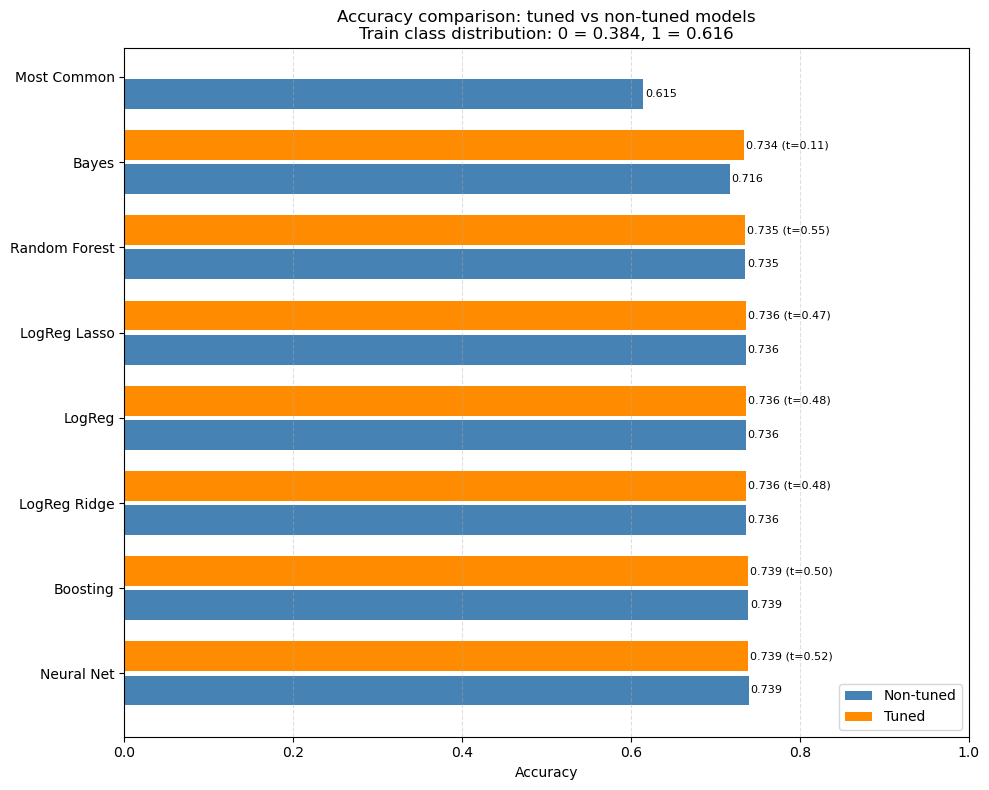

In [27]:
#making the accuracy comparison chart

models_acc = {
    'Most Common': (accuracy_score(y_test, y_pred_test_mc), None, None),
    'Bayes':        (accuracy_score(y_test, y_pred_test_bayes),
                     accuracy_score(y_test, y_pred_test_bayes_tunedacc), best_t_Bayes_acc),
    'LogReg':       (accuracy_score(y_test, y_pred_test_lrc),
                     accuracy_score(y_test, y_pred_lrcacc_test_best_thresh), best_threshold_lrc_acc),
    'LogReg Lasso': (accuracy_score(y_test, y_pred_test_lrc_lasso),
                     accuracy_score(y_test, y_pred_lrcacc_lasso_test_best_thresh), best_threshold_lrc_lasso_acc),
    'LogReg Ridge': (accuracy_score(y_test, y_pred_test_lrc_ridge),
                     accuracy_score(y_test, y_pred_lrcacc_ridge_test_best_thresh), best_threshold_lrc_ridge_acc),
    'Neural Net':   (accuracy_score(y_test, y_pred_test_neuron),
                     accuracy_score(y_test, y_pred_test_neuronacc_hyp), neuron_tuned.best_threshold_),
    'Random Forest':(accuracy_score(y_test, y_pred_test_rf),
                     accuracy_score(y_test, y_pred_test_tunedacc_rf), search.best_params_['threshold']),
    'Boosting':     (accuracy_score(y_test, y_pred_test_boosting),
                     accuracy_score(y_test, y_pred_test_boostingacc_hyp), boosting_tuned.best_threshold_),
}

rows = []
for name, (acc_base, acc_tuned, t) in models_acc.items():
    max_acc = max(acc_base, acc_tuned) if acc_tuned is not None else acc_base
    rows.append([name, acc_base, acc_tuned, t, max_acc])

df_acc = pd.DataFrame(rows, columns=['Model','Acc_base','Acc_tuned','Threshold','MaxAcc'])
df_acc = df_acc.sort_values('MaxAcc', ascending=False).reset_index(drop=True)

class_ratio = y_train.value_counts(normalize=True).sort_index()
neg, pos = class_ratio.iloc[0], class_ratio.iloc[1]

plt.figure(figsize=(10, 8))
y_pos = np.arange(len(df_acc))

plt.barh(y_pos - 0.2, df_acc['Acc_base'], height=0.35, color='steelblue', label='Non-tuned')
plt.barh(y_pos + 0.2, df_acc['Acc_tuned'], height=0.35, color='darkorange', label='Tuned')

for i, row in df_acc.iterrows():
    plt.text(row['Acc_base'] + 0.002, i - 0.2, f"{row['Acc_base']:.3f}", va='center', fontsize=8)
    if row['Acc_tuned'] is not None:
        txt = f"{row['Acc_tuned']:.3f} (t={row['Threshold']:.2f})" if row['Threshold'] is not None else f"{row['Acc_tuned']:.3f}"
        plt.text(row['Acc_tuned'] + 0.002, i + 0.2, txt, va='center', fontsize=8)

plt.yticks(y_pos, df_acc['Model'])
plt.xlabel('Accuracy')
plt.title(
    f'Accuracy comparison: tuned vs non-tuned models\n'
    f'Train class distribution: 0 = {neg:.3f}, 1 = {pos:.3f}'
)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.legend()
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

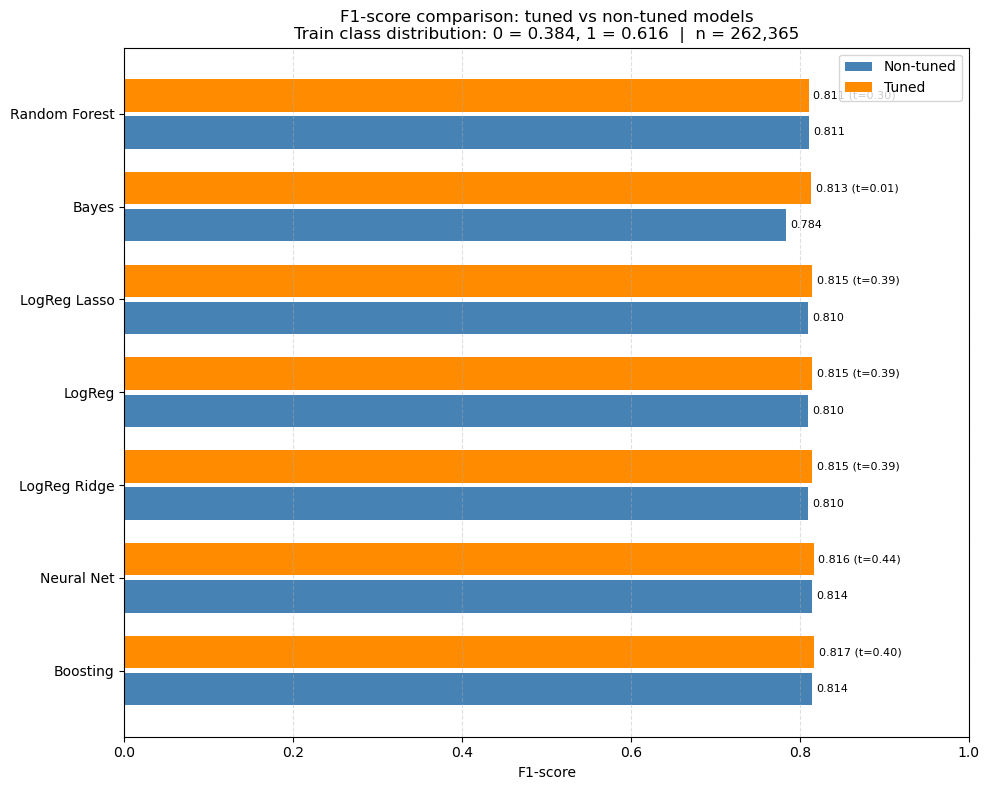

In [28]:
#making the chart for the F1 comparison

models_f1 = {
    'Bayes':        (f1_score(y_test, y_pred_test_bayes),
                     f1_score(y_test, y_pred_test_bayes_tunedf1), best_t_Bayes_f1),
    'LogReg':       (f1_score(y_test, y_pred_test_lrc),
                     f1_score(y_test, y_pred_lrcf1_test_best_thresh), best_threshold_lrc_f1),
    'LogReg Lasso': (f1_score(y_test, y_pred_test_lrc_lasso),
                     f1_score(y_test, y_pred_lrcf1_lasso_test_best_thresh), best_threshold_lrc_lasso_f1),
    'LogReg Ridge': (f1_score(y_test, y_pred_test_lrc_ridge),
                     f1_score(y_test, y_pred_lrcf1_ridge_test_best_thresh), best_threshold_lrc_ridge_f1),
    'Neural Net':   (f1_score(y_test, y_pred_test_neuron),
                     f1_score(y_test, y_pred_test_neuronf1_hyp), neuron_tuned_f1.best_threshold_),
    'Random Forest':(f1_score(y_test, y_pred_test_rf),
                     f1_score(y_test, y_pred_test_tunedf1_rf), searchf1.best_params_['threshold']),
    'Boosting':     (f1_score(y_test, y_pred_test_boosting),
                     f1_score(y_test, y_pred_test_boostingf1_hyp), boosting_tuned_f1.best_threshold_),
}

rows_f1 = []
for name, (f1_base, f1_tuned, t) in models_f1.items():
    max_f1 = max(f1_base, f1_tuned) if f1_tuned is not None else f1_base
    rows_f1.append([name, f1_base, f1_tuned, t, max_f1])

df_f1 = pd.DataFrame(rows_f1, columns=['Model','F1_base','F1_tuned','Threshold','MaxF1'])
df_f1 = df_f1.sort_values('MaxF1', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 8))
y_pos = np.arange(len(df_f1))

plt.barh(y_pos - 0.2, df_f1['F1_base'], height=0.35, color='steelblue', label='Non-tuned')
plt.barh(y_pos + 0.2, df_f1['F1_tuned'], height=0.35, color='darkorange', label='Tuned')

for i, row in df_f1.iterrows():
    plt.text(row['F1_base'] + 0.005, i - 0.2, f"{row['F1_base']:.3f}", va='center', fontsize=8)
    if row['F1_tuned'] is not None:
        txt = f"{row['F1_tuned']:.3f} (t={row['Threshold']:.2f})" if row['Threshold'] is not None else f"{row['F1_tuned']:.3f}"
        plt.text(row['F1_tuned'] + 0.005, i + 0.2, txt, va='center', fontsize=8)

plt.yticks(y_pos, df_f1['Model'])
plt.xlabel('F1-score')
plt.title(
    f'F1-score comparison: tuned vs non-tuned models\n'
    f'Train class distribution: 0 = {neg:.3f}, 1 = {pos:.3f}  |  n = {y_train.shape[0]:,}'
)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.legend()
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

,feature,importance
0,days_band_under_30,0.443452
1,bodyweight_change_band_lost_5plus,0.074978
2,bodyweight_change_band_gained_5plus,0.072004
3,bodyweight_change_band_gained_2_to_5,0.045383
4,days_band_180_to_365,0.042547
5,days_band_90_to_180,0.034815
6,bodyweight_change_band_lost_2_to_5,0.030242
7,age_band_25_to_30,0.024775
8,age_band_under_20,0.023188
9,days_band_30_to_90,0.022971


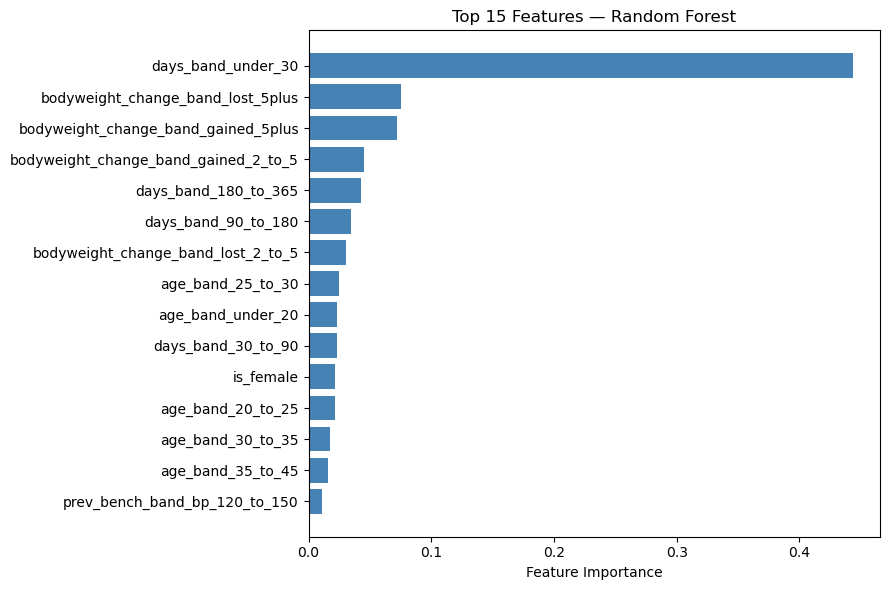

In [29]:
# feature importance for random forest 
# which features matter most for predicting whether a lifter improves?

feat_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

display(feat_importance.head(10).reset_index(drop=True))

# plot top 15 features
top15 = feat_importance.head(15)
plt.figure(figsize=(9, 6))
plt.barh(top15['feature'][::-1], top15['importance'][::-1], color='steelblue')
plt.xlabel('Feature Importance')
plt.title('Top 15 Features — Random Forest')
plt.tight_layout()
plt.show()

In [30]:
import pickle

# ---- MODEL SELECTION SUMMARY ----
# We evaluated 8 classifiers on accuracy and F1-score with threshold tuning.
# Results on the test set (tuned):
#
#   Model          Accuracy    F1
#   Neural Net     0.739       0.816
#   Boosting       0.737       0.818
#   LogReg         0.734       0.816
#   LogReg Lasso   0.734       0.816
#   LogReg Ridge   0.734       0.815
#   Naive Bayes    0.734       0.812
#   Random Forest  0.720       0.812
#
# The gap between Boosting/Neural Net and Logistic Regression is 0.5% accuracy
# and 0.002 F1 — not meaningful. Logistic Regression trains in seconds, makes
# predictions instantly, and uses minimal memory. The more complex models offer
# no meaningful benefit over it for this task.
#
# SELECTED MODEL: Logistic Regression (no penalty), threshold = 0.37

print('Best models by accuracy:')
print(df_acc[['Model','MaxAcc']].head(3).to_string(index=False))
print()
print('Best models by F1:')
print(df_f1[['Model','MaxF1']].head(3).to_string(index=False))
print()
print('Selected model: Logistic Regression (no penalty)')
print(f'Accuracy: {accuracy_score(y_test, y_pred_lrcf1_test_best_thresh):.3f}')
print(f'F1-score: {f1_score(y_test, y_pred_lrcf1_test_best_thresh):.3f}')
print(f'Threshold: {best_threshold_lrc_f1:.3f}')

# save the model and the feature column order so the Streamlit app can load them
with open('data/milo_model.pkl', 'wb') as f:
    pickle.dump(lrc, f)

with open('data/feature_columns.pkl', 'wb') as f:
    pickle.dump(list(X_train.columns), f)

print()
print('Model saved to data/milo_model.pkl')
print('Feature columns saved to data/feature_columns.pkl')

Best models by accuracy:
       Model   MaxAcc
  Neural Net 0.739406
    Boosting 0.738845
LogReg Ridge 0.736133

Best models by F1:
       Model    MaxF1
    Boosting 0.817084
  Neural Net 0.816097
LogReg Ridge 0.814729

Selected model: Logistic Regression (no penalty)
Accuracy: 0.734
F1-score: 0.815
Threshold: 0.390

Model saved to data/milo_model.pkl
Feature columns saved to data/feature_columns.pkl
